In [1]:
!pip install keras-tcn --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tcn import TCN
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU available: {[g.name for g in gpus]}")
else:
    print("No GPU found — go to Runtime > Change Runtime Type > GPU")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy().name)

GPU available: ['/physical_device:GPU:0']
Mixed precision policy: mixed_float16


In [5]:
# ── Update this to where your files are in Google Drive ───────────────────
DATA_DIR       = "/content/drive/MyDrive/ECG_Processed_Final"

X_TRAIN_PATH   = f"{DATA_DIR}/X_train.npy"
Y_TRAIN_PATH   = f"{DATA_DIR}/y_train.npy"
X_TEST_PATH    = f"{DATA_DIR}/X_test.npy"
Y_TEST_PATH    = f"{DATA_DIR}/y_test.npy"

# Checkpoints saved to Drive so they persist across Colab sessions
CHECKPOINT_DIR    = f"{DATA_DIR}/checkpoints"
CHECKPOINT_PATH   = f"{CHECKPOINT_DIR}/model_epoch_{{epoch:03d}}.keras"
BEST_MODEL_PATH   = f"{CHECKPOINT_DIR}/best_model.keras"
HISTORY_PATH      = f"{CHECKPOINT_DIR}/training_history.npy"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Training config
NUM_CLASSES   = 4
BATCH_SIZE    = 64
EPOCHS_TOTAL  = 60
INITIAL_LR    = 3e-4
RANDOM_STATE  = 42

# Hardcoded class weights
# Normal is majority → low weight
# AF and Other are hard/minority → high weight
# Noisy is very small but relatively easy → medium weight
CLASS_WEIGHTS = {
    0: 1.0,   # Normal (N)
    1: 4.0,   # AF (A)  — minority + clinically critical
    2: 3.5,   # Other (O) — most confused class in confusion matrix
    3: 2.5,   # Noisy (~)
}

LABEL_NAMES = ["Normal (N)", "AF (A)", "Other (O)", "Noisy (~)"]

print("Config loaded.")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

Config loaded.
Checkpoint directory: /content/drive/MyDrive/ECG_Processed_Final/checkpoints


In [6]:
print("Loading data...")
X_train = np.load(X_TRAIN_PATH)   # (32970, 4500, 1)
y_train = np.load(Y_TRAIN_PATH)   # (32970,)
X_test  = np.load(X_TEST_PATH)    # (5548, 4500, 1)
y_test  = np.load(Y_TEST_PATH)    # (5548,)

INPUT_SHAPE = X_train.shape[1:]   # (4500, 1)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# One-hot encode
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("\nTrain class distribution:")
for u, c in zip(unique, counts):
    print(f"  Class {u} ({LABEL_NAMES[u]}): {c} samples")

Loading data...
X_train: (32970, 4500, 1)  y_train: (32970,)
X_test:  (5548, 4500, 1)   y_test:  (5548,)

Train class distribution:
  Class 0 (Normal (N)): 13028 samples
  Class 1 (AF (A)): 10000 samples
  Class 2 (Other (O)): 6942 samples
  Class 3 (Noisy (~)): 3000 samples


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True, seed=RANDOM_STATE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train_oh, shuffle=True)
test_ds  = make_dataset(X_test,  y_test_oh,  shuffle=False)

print("tf.data pipelines ready.")

tf.data pipelines ready.


In [8]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-8, 1.0)
        ce      = -y_true * tf.math.log(y_pred)
        pt      = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_w = alpha * tf.pow(1.0 - pt, gamma)
        return tf.reduce_mean(focal_w * ce)
    return loss_fn

In [9]:
def residual_block(x, filters, kernel_size=3, dilation=1, dropout=0.2):
    shortcut = x

    x = layers.Conv1D(filters, kernel_size, padding="causal",
                      dilation_rate=dilation,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv1D(filters, kernel_size, padding="causal",
                      dilation_rate=dilation,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x


def build_hybrid_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape, name="ecg_input")

    # ── Branch 1: TCN ─────────────────────────────────────────────────────
    tcn_out = TCN(
        nb_filters           = 128,
        kernel_size          = 3,
        nb_stacks            = 2,
        dilations            = [1, 2, 4, 8, 16, 32, 64],
        padding              = "causal",
        use_skip_connections = True,
        dropout_rate         = 0.3,
        return_sequences     = True,    # keep sequence for concat with ResNet
        activation           = "relu",
        kernel_initializer   = "he_normal",
        use_batch_norm       = True,
        name                 = "tcn_branch"
    )(inputs)

    # ── Branch 2: ResNet1D ────────────────────────────────────────────────
    res = layers.Conv1D(64, 7, padding="causal", strides=2)(inputs)
    res = layers.BatchNormalization()(res)
    res = layers.Activation("relu")(res)
    res = layers.MaxPooling1D(pool_size=3, strides=2, padding="same")(res)

    res = residual_block(res, filters=64,  dilation=1)
    res = residual_block(res, filters=64,  dilation=2)
    res = residual_block(res, filters=128, dilation=4)
    res = residual_block(res, filters=128, dilation=8)
    res = residual_block(res, filters=256, dilation=16)
    res = residual_block(res, filters=256, dilation=32)

    # ── Merge both branches ───────────────────────────────────────────────
    # TCN output: (batch, 4500, 128) → Global avg pool → (batch, 128)
    # ResNet output: (batch, ~280, 256) → Global avg pool → (batch, 256)
    tcn_pooled = layers.GlobalAveragePooling1D(name="tcn_pool")(tcn_out)
    res_pooled = layers.GlobalAveragePooling1D(name="res_pool")(res)

    # Concatenate both representations
    merged = layers.Concatenate(name="merge")([tcn_pooled, res_pooled])

    # ── Classification Head ───────────────────────────────────────────────
    x = layers.Dense(512, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax",
                           dtype="float32", name="output")(x)

    return keras.Model(inputs, outputs, name="TCN_ResNet1D_Hybrid")

In [10]:
def get_latest_checkpoint(checkpoint_dir):
    """Find the most recently saved epoch checkpoint."""
    files = [f for f in os.listdir(checkpoint_dir) if f.startswith("model_epoch_") and f.endswith(".keras")]
    if not files:
        return None, 0
    files.sort()   # sorts by epoch number due to zero-padded naming
    latest = files[-1]
    epoch  = int(latest.replace("model_epoch_", "").replace(".keras", ""))
    return os.path.join(checkpoint_dir, latest), epoch


latest_ckpt, epochs_done = get_latest_checkpoint(CHECKPOINT_DIR)

if latest_ckpt is not None:
    print(f"Resuming from: {latest_ckpt}  (epoch {epochs_done})")
    model = keras.models.load_model(
        latest_ckpt,
        custom_objects={"TCN": TCN, "loss_fn": focal_loss(gamma=2.0, alpha=0.25)}
    )
else:
    print("No checkpoint found — building model from scratch")
    model = build_hybrid_model(INPUT_SHAPE, NUM_CLASSES)
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=INITIAL_LR, clipnorm=1.0),
        loss      = focal_loss(gamma=2.0, alpha=0.25),
        metrics   = [
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

model.summary()
print(f"\nEpochs already completed: {epochs_done}")
print(f"Epochs remaining: {EPOCHS_TOTAL - epochs_done}")

No checkpoint found — building model from scratch


Model: "TCN_ResNet1D_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 4500, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2250, 64)  │        512 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2250, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2250, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1125, 64)  │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1125, 64)  │     12,352 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1125, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1125, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1125, 64)  │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1125, 64)  │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1125, 64)  │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1125, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1125, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1125, 64)  │     12,352 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1125, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1125, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1125, 64)  │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1125, 64)  │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1125, 64)  │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 2,669,956 (10.19 MB)

 Trainable params: 2,658,052 (10.14 MB)

 Non-trainable params: 11,904 (46.50 KB)


Epochs already completed: 0
Epochs remaining: 60


In [11]:
cb_list = [
    # Save every epoch — named by epoch number for easy resume
    callbacks.ModelCheckpoint(
        filepath       = CHECKPOINT_PATH,
        save_best_only = False,    # save every epoch so we can always resume
        verbose        = 1
    ),
    # Separately track best model by val_loss
    callbacks.ModelCheckpoint(
        filepath       = BEST_MODEL_PATH,
        monitor        = "val_loss",
        save_best_only = True,
        verbose        = 1
    ),
    callbacks.ReduceLROnPlateau(
        monitor   = "val_loss",
        factor    = 0.5,
        patience  = 5,
        min_lr    = 1e-6,
        verbose   = 1
    ),
    callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 15,
        restore_best_weights = True,
        verbose              = 1
    ),
]

print("Callbacks ready.")

Callbacks ready.


In [12]:
if epochs_done >= EPOCHS_TOTAL:
    print("Training already complete! Load best model and evaluate.")
else:
    history = model.fit(
        train_ds,
        initial_epoch   = epochs_done,       # resume from correct epoch
        epochs          = EPOCHS_TOTAL,       # global total
        validation_data = test_ds,
        class_weight    = CLASS_WEIGHTS,
        callbacks       = cb_list,
        verbose         = 1
    )

    # ── Merge with previous history if resuming ────────────────────────────
    if os.path.exists(HISTORY_PATH):
        old_history = np.load(HISTORY_PATH, allow_pickle=True).item()
        merged      = {}
        for key in history.history:
            merged[key] = old_history.get(key, []) + history.history[key]
    else:
        merged = history.history

    np.save(HISTORY_PATH, merged)
    print(f"\nHistory saved — total epochs completed: {len(merged['loss'])}")

Epoch 1/60
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.4676 - auc: 0.7366 - loss: 0.3513 - precision: 0.5186 - recall: 0.3341
Epoch 1: saving model to /content/drive/MyDrive/ECG_Processed_Final/checkpoints/model_epoch_001.keras

Epoch 1: val_loss improved from inf to 0.18561, saving model to /content/drive/MyDrive/ECG_Processed_Final/checkpoints/best_model.keras
516/516 ━━━━━━━━━━━━━━━━━━━━ 537s 783ms/step - accuracy: 0.4678 - auc: 0.7367 - loss: 0.3512 - precision: 0.5189 - recall: 0.3342 - val_accuracy: 0.6476 - val_auc: 0.8812 - val_loss: 0.1856 - val_precision: 0.7168 - val_recall: 0.5202 - learning_rate: 3.0000e-04
Epoch 2/60
516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.7111 - auc: 0.9135 - loss: 0.1975 - precision: 0.7845 - recall: 0.5927
Epoch 2: saving model to /content/drive/MyDrive/ECG_Processed_Final/checkpoints/model_epoch_002.keras

Epoch 2: val_loss improved from 0.18561 to 0.16256, saving model to /content/drive/MyDrive/ECG_Processed_Final/checkp

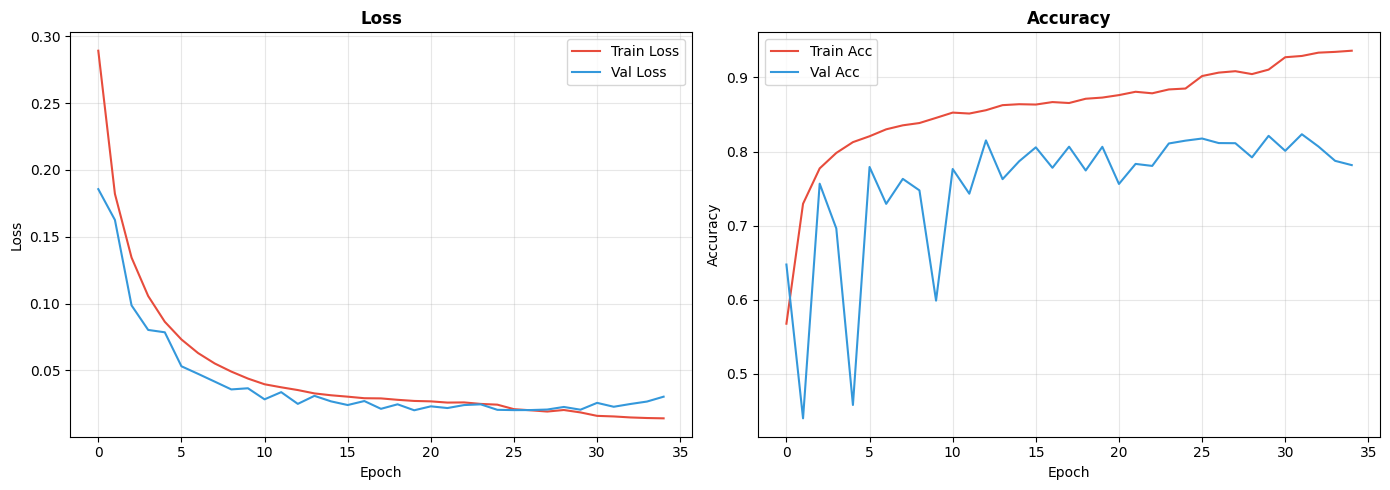

Best val accuracy: 0.8234
Best val loss:     0.0201


In [13]:
def plot_training_history(history_path):
    if not os.path.exists(history_path):
        print("No history file found.")
        return

    h   = np.load(history_path, allow_pickle=True).item()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(h["loss"],     label="Train Loss", color="#e74c3c", linewidth=1.5)
    axes[0].plot(h["val_loss"], label="Val Loss",   color="#3498db", linewidth=1.5)
    axes[0].set_title("Loss", fontweight="bold", fontsize=12)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(h["accuracy"],     label="Train Acc", color="#e74c3c", linewidth=1.5)
    axes[1].plot(h["val_accuracy"], label="Val Acc",   color="#3498db", linewidth=1.5)
    axes[1].set_title("Accuracy", fontweight="bold", fontsize=12)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Best val accuracy: {max(h['val_accuracy']):.4f}")
    print(f"Best val loss:     {min(h['val_loss']):.4f}")

plot_training_history(HISTORY_PATH)

In [14]:
print("Loading best model for evaluation...")
best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={"TCN": TCN, "loss_fn": focal_loss(gamma=2.0, alpha=0.25)}
)

y_pred_prob = best_model.predict(test_ds, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, digits=4))

Loading best model for evaluation...
87/87 ━━━━━━━━━━━━━━━━━━━━ 31s 255ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (N)     0.8203    0.9469    0.8791      3220
      AF (A)     0.7407    0.8434    0.7887       498
   Other (O)     0.8394    0.5425    0.6590      1696
   Noisy (~)     0.5060    0.6343    0.5629       134

    accuracy                         0.8064      5548
   macro avg     0.7266    0.7418    0.7224      5548
weighted avg     0.8114    0.8064    0.7960      5548



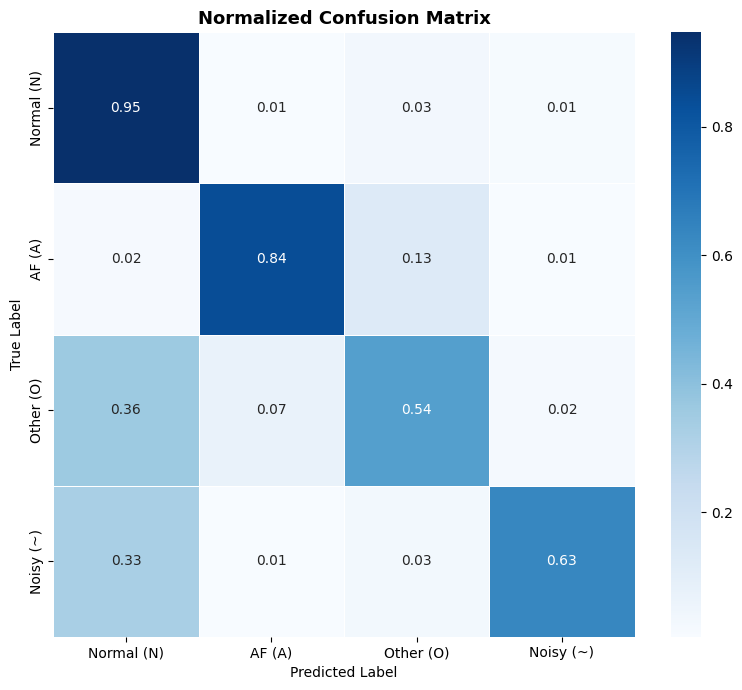

In [15]:
def plot_confusion_matrix(y_true, y_pred, class_names, save_dir):
    cm  = confusion_matrix(y_true, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_title("Normalized Confusion Matrix", fontsize=13, fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_confusion_matrix(y_test, y_pred, LABEL_NAMES, CHECKPOINT_DIR)